<a href="https://colab.research.google.com/github/lhiwi/FUTURE_DS_03/blob/main/notebooks/funnel_analysis_and_insights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Funnel Analysis and Conversion Insights

This notebook analyzes marketing campaign conversion performance using the cleaned Bank Marketing dataset.

## Goal
The goal is to identify overall conversion performance, major drop-off points, high-performing customer segments, and campaign conditions that can improve conversion rates.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
file_path = "/content/drive/MyDrive/Future_DS/FUTURE_DS_03/data/bank_cleaned.csv"
df=pd.read_csv(file_path)

In [ ]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,was_contacted_before,conversion_flag
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,no,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,no,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,no,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,no,0


In [ ]:
df.shape

(45211, 19)

## Define funnel and key metric

In this dataset, the marketing funnel represents:

- All contacted customers
- Customers exposed to different campaign conditions
- Customers who converted (y = yes)
- Customers who did not convert (drop-off)

The key metric is the overall conversion rate, which represents the proportion of customers who successfully converted.

In [ ]:
#calculating overall coversion rate
conversion_rate = df['conversion_flag'].mean() * 100
conversion_rate

np.float64(11.698480458295547)

## Overall conversion and drop-off summary

We calculate the number of converted and non-converted customers to summarize the campaign funnel outcome.

In [ ]:
funnel_summary = df['y'].value_counts().reset_index()
funnel_summary.columns = ['outcome', 'customer_count']

funnel_summary

,outcome,customer_count
0,no,39922
1,yes,5289


## Funnel outcome visualization

visualization of the number of converted and non-converted customers to clearly show the drop-off in the marketing funnel.

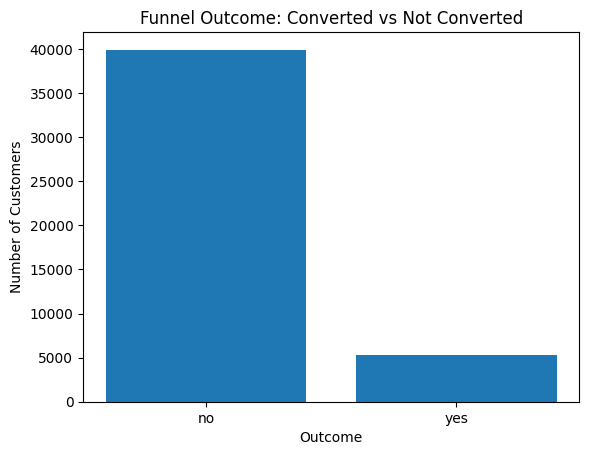

In [ ]:
plt.figure()
plt.bar(funnel_summary['outcome'], funnel_summary['customer_count'])
plt.title("Funnel Outcome: Converted vs Not Converted")
plt.xlabel("Outcome")
plt.ylabel("Number of Customers")

plt.show()

## Conversion rate by contact type

We analyze how conversion performance varies across different contact channels (e.g., cellular, telephone, unknown) to identify which channels are most effective.

In [ ]:
contact_conversion = df.groupby('contact')['conversion_flag'].mean().sort_values(ascending=False) * 100
contact_conversion

,conversion_flag
contact,
cellular,14.918900
telephone,13.420509
unknown,4.070661


## Visualization: conversion rate by contact type

We visualize conversion rates across contact channels to clearly compare performance and identify the most effective communication method.

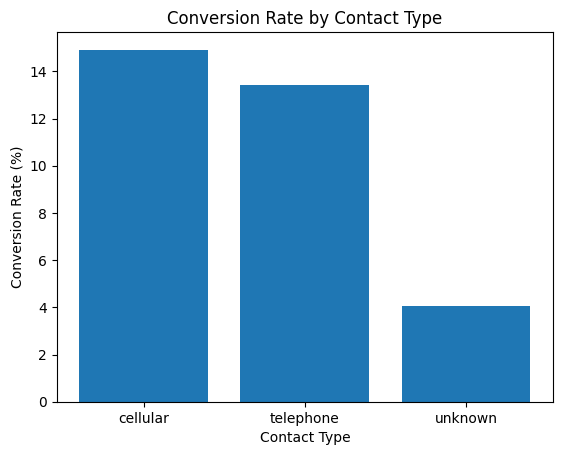

In [ ]:
plt.figure()
plt.bar(contact_conversion.index, contact_conversion.values)
plt.title("Conversion Rate by Contact Type")
plt.xlabel("Contact Type")
plt.ylabel("Conversion Rate (%)")

plt.show()

## Conversion rate by previous contact

We compare conversion rates between customers who were previously contacted and those who were not, to evaluate the impact of prior engagement on conversion.

In [ ]:
previous_contact_conversion = (
    df.groupby('was_contacted_before')['conversion_flag']
      .mean()
      .sort_values(ascending=False) * 100
)

previous_contact_conversion

,conversion_flag
was_contacted_before,
yes,23.071333
no,9.157331


## Visualization: conversion rate by previous contact

We visualize how prior engagement affects conversion rates to clearly show the difference between new and returning customers.

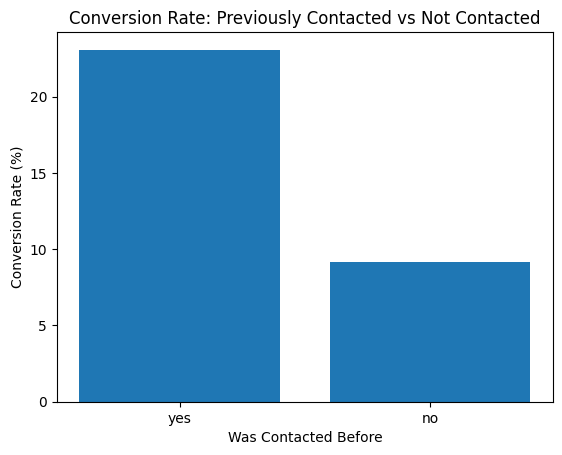

In [ ]:
plt.figure()
plt.bar(previous_contact_conversion.index, previous_contact_conversion.values)
plt.title("Conversion Rate: Previously Contacted vs Not Contacted")
plt.xlabel("Was Contacted Before")
plt.ylabel("Conversion Rate (%)")

plt.show()

## Conversion rate by job

We analyze conversion rates across different job categories to identify which customer segments are more likely to convert.

In [ ]:
job_conversion = (
    df.groupby('job')['conversion_flag']
      .mean()
      .sort_values(ascending=False) * 100
)

job_conversion

,conversion_flag
job,
student,28.678038
retired,22.791519
unemployed,15.502686
management,13.755551
admin.,12.202669
self-employed,11.842939
unknown,11.805556
technician,11.056996
services,8.883004


## Visualization: conversion rate by job

We visualize conversion rates across job categories to identify high-performing and low-performing customer segments.

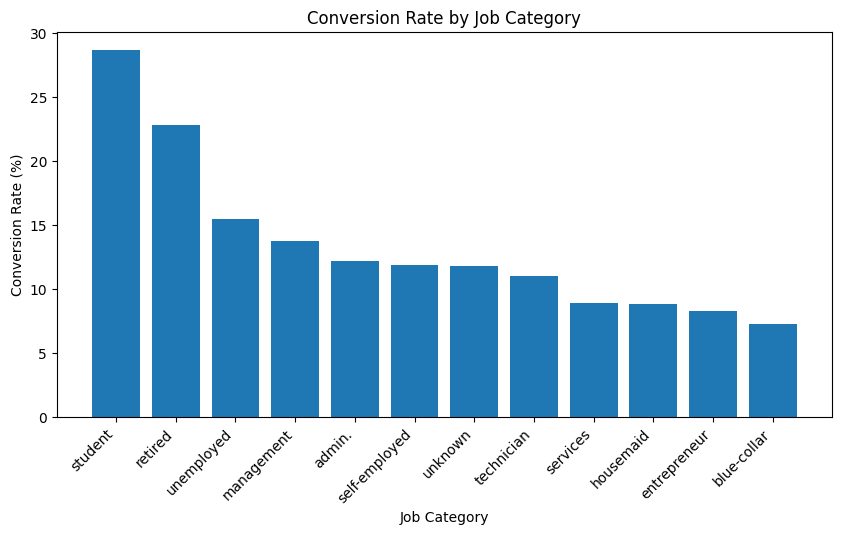

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(job_conversion.index, job_conversion.values)
plt.title("Conversion Rate by Job Category")
plt.xlabel("Job Category")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=45, ha='right')

plt.show()

## Conversion rate by education level

We analyze how conversion rates vary across education levels to understand whether educational background influences campaign effectiveness.

In [ ]:
education_conversion = (
    df.groupby('education')['conversion_flag']
      .mean()
      .sort_values(ascending=False) *100
)
education_conversion

,conversion_flag
education,
tertiary,15.006390
unknown,13.570275
secondary,10.559435
primary,8.626478


## Visualization: conversion rate by education

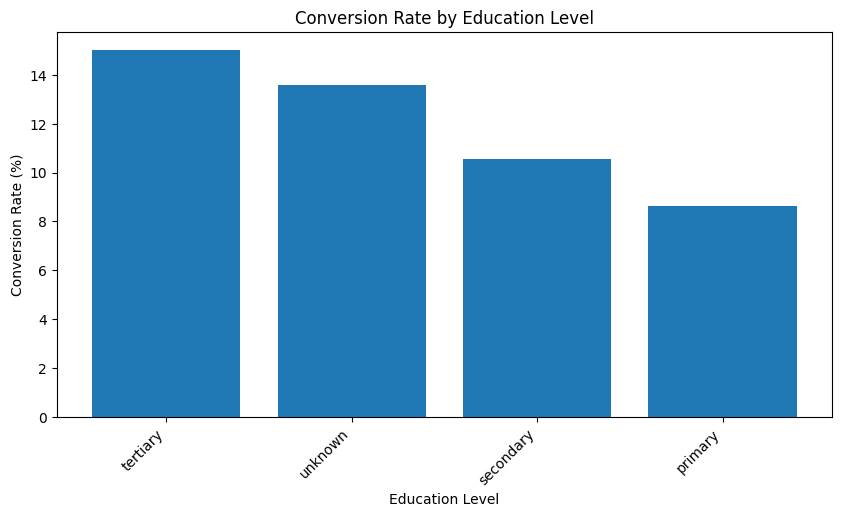

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(education_conversion.index, education_conversion.values)
plt.title("Conversion Rate by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=45, ha='right')

plt.show()

## Prepare data for dashboard

We create summary tables that will be used in Power BI to build the funnel dashboard and visualize key performance metrics.

In [ ]:
# 1. Funnel summary
funnel_summary.to_csv("/content/drive/MyDrive/Future_DS/FUTURE_DS_03/data/funnel_summary.csv", index=False)

# 2. Contact conversion
contact_conversion.reset_index().to_csv("/content/drive/MyDrive/Future_DS/FUTURE_DS_03/data/contact_conversion.csv", index=False)

# 3. Previous contact conversion
previous_contact_conversion.reset_index().to_csv("/content/drive/MyDrive/Future_DS/FUTURE_DS_03/data/previous_contact_conversion.csv", index=False)

# 4. Job conversion
job_conversion.reset_index().to_csv("/content/drive/MyDrive/Future_DS/FUTURE_DS_03/data/job_conversion.csv", index=False)

# 5. Education conversion
education_conversion.reset_index().to_csv("/content/drive/MyDrive/Future_DS/FUTURE_DS_03/data/education_conversion.csv", index=False)